# SIBI Static Keypoint Classifier (Phase 2D)

Trains a small MLP that maps 84-float landmark vectors (2 hands × 21 landmarks × 2 coords) to SIBI alphabet classes. Class list is derived from the actual data in `keypoint_csv/sibi.csv` (collected via `/dev/gesture-recorder` or `frontend/public/recorder.html`) — J and Z should be collected in the dynamic notebook instead.

Output: `keypoint_classifier.keras`, `keypoint_classifier.tflite`.

In [6]:
import csv
import os
# Cap TF native threads BEFORE importing tf — improves stability on
# weaker CPUs. Required env vars are read only at first import.
os.environ.setdefault('TF_NUM_INTEROP_THREADS', '2')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS', '4')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')  # silence INFO/WARN

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
FEATURE_LENGTH = 84  # 2 hands × 21 landmarks × 2 coords
CSV_PATH = 'keypoint_csv/sibi_aug.csv'
LABEL_CSV_PATH = 'keypoint_csv/sibi_label.csv'
MODEL_PATH = 'keypoint_classifier.keras'
# Same SavedModel path approach as the dynamic notebook — skip the legacy
# .tflite step (avoids TFLiteConverter LSTM segfault and keeps both
# notebooks consistent even though static MLP wouldn't trip that bug).
SAVED_MODEL_DIR = 'keypoint_classifier_saved_model'

In [7]:
# Load dataset and derive labels + NUM_CLASSES from data.
df = pd.read_csv(CSV_PATH)
print(f'Total samples: {len(df)}')
print(f'Samples per class:\n{df["label"].value_counts()}')

labels = sorted(df['label'].astype(str).unique().tolist())
NUM_CLASSES = len(labels)
print(f'Derived {NUM_CLASSES} classes from data: {labels}')

# Persist label order so convert_to_tfjs.sh emits labels.json that matches
# the trained model's softmax argmax index.
pd.Series(labels).to_csv(LABEL_CSV_PATH, index=False, header=False)
print(f'Wrote {LABEL_CSV_PATH} with {NUM_CLASSES} class names.')

label_to_idx = {l: i for i, l in enumerate(labels)}
X = df.iloc[:, 1:].astype(np.float32).values
y_strings = df['label'].astype(str).values
y = np.array([label_to_idx[l] for l in y_strings], dtype=np.int32)
assert X.shape[1] == FEATURE_LENGTH, f'Expected {FEATURE_LENGTH} features, got {X.shape[1]}'
print(f'X shape: {X.shape}, y shape: {y.shape}')

Total samples: 19200
Samples per class:
label
L    800
U    800
E    800
D    800
I    800
S    800
A    800
T    800
C    800
O    800
N    800
H    800
X    800
V    800
B    800
P    800
R    800
Y    800
G    800
Q    800
M    800
F    800
K    800
W    800
Name: count, dtype: int64
Derived 24 classes from data: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Wrote keypoint_csv/sibi_label.csv with 24 class names.
X shape: (19200, 84), y shape: (19200,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=RANDOM_SEED, stratify=y
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 14400, Test: 4800


In [9]:
# Small MLP — same shape philosophy as Kazuhito's keypoint classifier,
# scaled up for our 84-input + 25-output dimensions.
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((FEATURE_LENGTH,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(40, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_3 (Dropout)             │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │         3,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │           504 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,724 (18.45 KB)

 Trainable params: 4,724 (18.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH, verbose=1, save_weights_only=False, save_best_only=True,
)
# Smaller patience + epoch cap so a flaky env doesn't run for hours before
# any potential crash. Tiny MLP on 4898 train samples converges within ~100
# epochs typically.
es_callback = tf.keras.callbacks.EarlyStopping(patience=500, verbose=1, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=1000,
    batch_size=64,           # smaller batch — less memory pressure
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback],
    verbose=2,
)

Epoch 1/1000

Epoch 1: val_loss improved from None to 2.54143, saving model to keypoint_classifier.keras
225/225 - 2s - 11ms/step - accuracy: 0.0983 - loss: 2.9881 - val_accuracy: 0.2965 - val_loss: 2.5414
Epoch 2/1000

Epoch 2: val_loss improved from 2.54143 to 1.98084, saving model to keypoint_classifier.keras
225/225 - 1s - 3ms/step - accuracy: 0.1923 - loss: 2.5419 - val_accuracy: 0.5252 - val_loss: 1.9808
Epoch 3/1000

Epoch 3: val_loss improved from 1.98084 to 1.68686, saving model to keypoint_classifier.keras
225/225 - 1s - 3ms/step - accuracy: 0.2441 - loss: 2.2703 - val_accuracy: 0.5833 - val_loss: 1.6869
Epoch 4/1000

Epoch 4: val_loss improved from 1.68686 to 1.50385, saving model to keypoint_classifier.keras
225/225 - 1s - 3ms/step - accuracy: 0.2985 - loss: 2.0873 - val_accuracy: 0.6767 - val_loss: 1.5038
Epoch 5/1000

Epoch 5: val_loss improved from 1.50385 to 1.37253, saving model to keypoint_classifier.keras
225/225 - 1s - 3ms/step - accuracy: 0.3283 - loss: 1.9586 - va

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           A      0.828     0.985     0.900       200
           B      0.783     0.650     0.710       200
           C      0.950     0.570     0.713       200
           D      0.975     0.780     0.867       200
           E      0.295     0.215     0.249       200
           F      0.844     0.620     0.715       200
           G      0.684     0.985     0.807       200
           H      0.980     0.975     0.977       200
           I      0.970     0.965     0.967       200
           K      0.819     0.925     0.869       200
           L      0.995     0.985     0.990       200
           M      0.623     0.380     0.472       200
           N      0.446     0.985     0.614       200
           O      0.660     0.825     0.733       200
           P      0.736     0.960     0.833       200
           Q      0.929     0.655     0.768       200
           R      0.553     0.960     0.

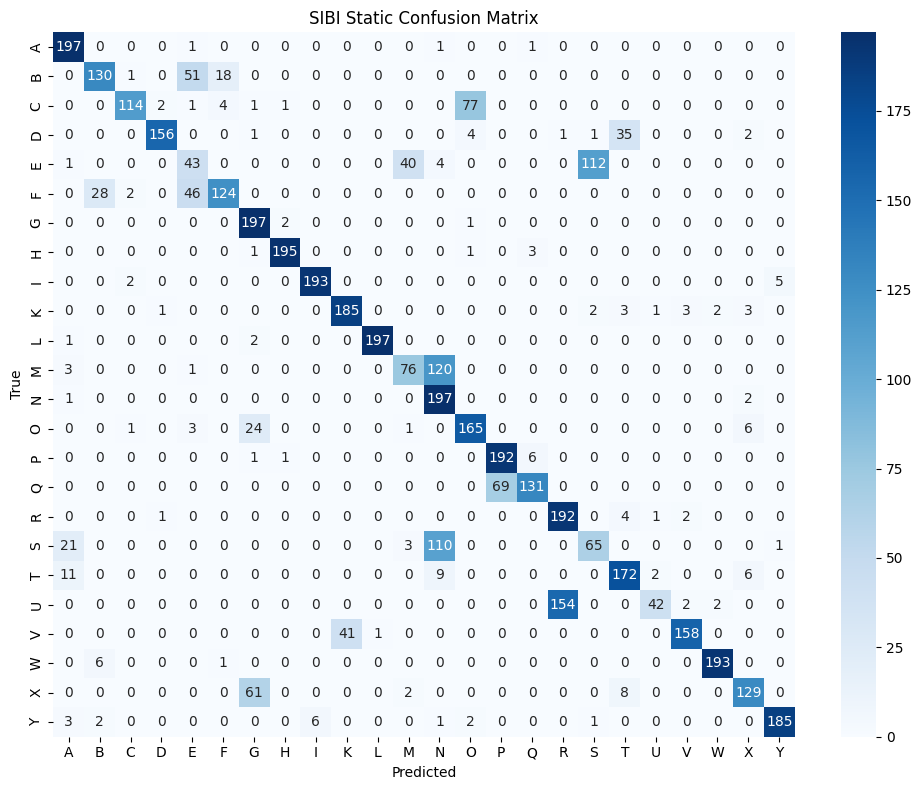

In [11]:
# Confusion matrix + per-class report
model = tf.keras.models.load_model(MODEL_PATH)
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=labels, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SIBI Static Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
# Export as TF SavedModel for the TFJS converter. We skip the legacy
# TFLite intermediate to keep both notebooks aligned (the dynamic LSTM
# notebook can't use TFLiteConverter reliably on TF 2.16+).
# tensorflowjs_converter --input_format=tf_saved_model reads this directly.
model.export(SAVED_MODEL_DIR)
print(f'Wrote SavedModel to {SAVED_MODEL_DIR}/')

INFO:tensorflow:Assets written to: keypoint_classifier_saved_model/assets


INFO:tensorflow:Assets written to: keypoint_classifier_saved_model/assets


Saved artifact at 'keypoint_classifier_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 84), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  139757430919888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139757938761344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139757938767152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139757939056784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139757939058544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139757939346768: TensorSpec(shape=(), dtype=tf.resource, name=None)
Wrote SavedModel to keypoint_classifier_saved_model/
